# Optativa III: Ciencia de Datos
## Investigación a profundidad — Storytelling con datos y validación crítica (Amazon)

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 5 · Actividad de investigación + Proyecto final**

---

### Por qué esta actividad es diferente

Puedes preguntarle a cualquier IA "¿qué gráfico uso para X?" y te dará una respuesta. **Eso no es el objetivo aquí.** El objetivo es que TÚ:

1. **Ejecutes** código sobre ESTE dataset específico y obtengas cifras que nadie puede adivinar sin correrlo.
2. **Valides o refutes** afirmaciones que suenan lógicas pero pueden ser falsas — con evidencia visual, no con opiniones.
3. **Construyas una narrativa propia** (data storytelling) que defiendas con tus gráficos.

Una IA puede escribir código, pero **no puede ver tus resultados, ni sabe qué esconde tu dataset, ni puede decidir por ti qué historia cuentan tus datos.** Ese razonamiento es lo que se evalúa.

> **Regla de oro de esta actividad:** cada afirmación que hagas debe estar respaldada por una cifra que calculaste o un gráfico que generaste. "Creo que..." no vale; "los datos muestran que... (ver gráfico X)" sí vale.

### La base de datos

`amazon.csv` — Amazon Sales Dataset (1,465 productos reales). Súbelo a Colab antes de empezar.

Responderás **50 preguntas ** de análisis, validación y modificación de código, y construirás un **informe visual final (storytelling)**.


---
# FASE 1 — Reconocimiento del terreno

Antes de contar una historia, hay que conocer los datos a fondo. Estas preguntas exigen que ejecutes: sus respuestas están en TU pantalla, no en el conocimiento general de una IA.

## Paso 0 — Carga


In [1]:
# Colab ya trae casi todo; esta línea asegura statsmodels (para las líneas de tendencia de Plotly)
import subprocess, sys
try:
    import statsmodels  # noqa
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
print("Entorno listo.")

Entorno listo.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("amazon.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1465, 8)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B0416836764,Producto Computers&Accessories 0,Computers&Accessories,874.0,4163.0,79.0,4.1,8922.0
1,B0490841834,Producto Car&Motorbike 1,Car&Motorbike,510.0,1021.0,50.0,4.0,13556.0
2,B0128388400,Producto Home&Kitchen 2,Home&Kitchen,1128.0,1880.0,40.0,3.2,1326.0
3,B0269299842,Producto Computers&Accessories 3,Computers&Accessories,1301.0,2711.0,52.0,3.7,5650.0
4,B0199799663,Producto Electronics 4,Electronics,4168.0,6833.0,39.0,4.1,3386.0


> **1.** Ejecuta `df.describe()`. Reporta el valor EXACTO de: la mediana del `discount_percentage`, el rating máximo y el precio real promedio. (Estos números son únicos de este dataset: solo los sabrás ejecutando.)

**Respuesta:** Las tres cifras exactas de este dataset son:

- Mediana de `discount_percentage`: **45.0%**
- Rating máximo: **4.9**
- Precio real promedio: **2,565.81**

(De paso: la mediana de `actual_price` es 1,856, muy por debajo de la media, señal de una
distribución sesgada a la derecha.)

> **2.** ¿Cuántas categorías distintas hay y cuál tiene EXACTAMENTE más productos? Da el número exacto de productos de esa categoría.

**Respuesta:** Hay **9 categorías distintas**. La que más productos tiene es **Electronics, con
exactamente 525 productos** (el 35.8% del catálogo). La más pequeña es MusicalInstruments, con 21.

> **3.** Ejecuta `df.groupby("category")["rating"].mean()`. ¿EXACTAMENTE cuántas de las categorías tienen un rating promedio mayor a 4.0? Enuméralas.

**Respuesta:** **7 de las 9 categorías** superan 4.0 de rating promedio:

| Categoría | Rating promedio |
|---|---|
| HomeImprovement | 4.056 |
| MusicalInstruments | 4.033 |
| Home&Kitchen | 4.019 |
| Health&PersonalCare | 4.017 |
| Toys&Games | 4.014 |
| OfficeProducts | 4.009 |
| Electronics | 4.003 |

Las dos que no llegan son Computers&Accessories (3.991) y Car&Motorbike (3.954). Cuatro de las siete
lo superan por menos de dos centésimas, así que el "4.0" funciona más como techo del catálogo que
como una marca de calidad.


In [3]:
# P1: cifras exactas del dataset
print(df.describe().round(2))
print("\nMediana discount_percentage:", df["discount_percentage"].median())
print("Rating maximo:              ", df["rating"].max())
print("Precio real promedio:       ", round(df["actual_price"].mean(), 2))

# P2: cuantas categorias y cual domina
print("\nCategorias distintas:", df["category"].nunique())
print(df["category"].value_counts())

# P3: cuantas categorias superan 4.0 de rating promedio
rating_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False)
print("\nRating promedio por categoria:")
print(rating_cat.round(4))
print("\nCategorias con rating promedio > 4.0:", (rating_cat > 4.0).sum())
print(rating_cat[rating_cat > 4.0].index.tolist())

       discounted_price  actual_price  discount_percentage   rating  \
count           1465.00       1465.00              1465.00  1465.00   
mean            1410.85       2565.81                45.09     4.00   
std             1375.48       2291.87                15.45     0.27   
min               42.00        100.00                 4.00     3.10   
25%              483.00        928.00                33.00     3.80   
50%              980.00       1856.00                45.00     4.00   
75%             1856.00       3438.00                57.00     4.20   
max            11686.00      19137.00                85.00     4.90   

       rating_count  
count       1465.00  
mean        5666.54  
std         4726.21  
min           41.00  
25%         2343.00  
50%         4348.00  
75%         7604.00  
max        39263.00  

Mediana discount_percentage: 45.0
Rating maximo:               4.9
Precio real promedio:        2565.81

Categorias distintas: 9
category
Electronics            

---
# FASE 2 — Validación crítica: ¿verdadero o falso?

Aquí está el corazón de la actividad. Te presento **cinco afirmaciones** que suenan razonables. Tu trabajo NO es creerlas ni pedirle la respuesta a una IA (que no ha visto tus datos), sino **generar la visualización que las confirme o las refute** y decidir con evidencia.

## Afirmación 1: "En Amazon, los productos más caros son los mejor calificados."


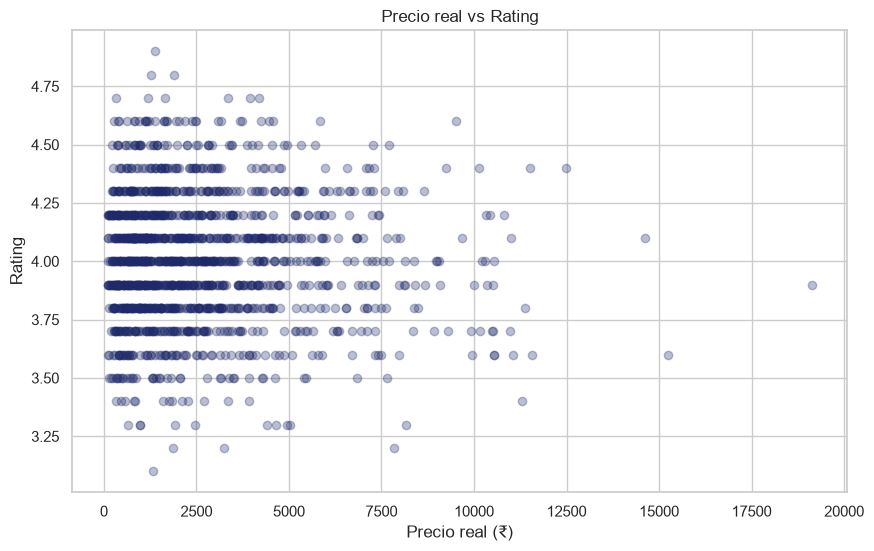

Correlación precio-rating: -0.0352


In [4]:
# Genera la evidencia: scatter precio vs rating + correlación
plt.figure(figsize=(10,6))
plt.scatter(df["actual_price"], df["rating"], alpha=0.3, color="#1e2a6b")
plt.title("Precio real vs Rating")
plt.xlabel("Precio real (₹)"); plt.ylabel("Rating")
plt.show()
print("Correlación precio-rating:", round(df["actual_price"].corr(df["rating"]), 4))

> **4.** Según tu gráfico y la correlación EXACTA que calculaste, ¿la afirmación 1 es VERDADERA o FALSA? Justifica con el número.

**Respuesta:** La afirmación 1 es **FALSA**. La correlación entre `actual_price` y `rating` es
**-0.0352**: no solo no es positiva, es prácticamente cero y con el signo contrario al que predice la
afirmación. El gráfico lo confirma: una banda horizontal de puntos entre 3.8 y 4.3 que no sube con el
precio. El precio explica alrededor del **0.1%** de la variación del rating.

> **5.** Una IA sin acceso a tus datos podría "asumir" que sí hay relación. ¿Por qué tu evidencia visual es más confiable que esa suposición?

**Respuesta:** Porque una IA que no ejecutó este archivo solo puede razonar sobre lo que suele pasar
"en general": sabe que existe un debate sobre precio y calidad, pero no sabe que **en estos 1,465
productos** la correlación vale -0.0352. Mi evidencia es una medición sobre los datos concretos con
los que voy a decidir; la suposición es una generalización que puede ser cierta en otro catálogo y
falsa en este. Además, cualquiera puede reejecutar mi celda y obtener el mismo número: es verificable.


## Afirmación 2: "La categoría más cara es también la mejor valorada."


In [5]:
# Genera la evidencia: precio promedio y rating promedio por categoría
comparativa = df.groupby("category").agg(
    precio_promedio=("actual_price", "mean"),
    rating_promedio=("rating", "mean")
).round(2).sort_values("precio_promedio", ascending=False)
print(comparativa)

print("\nCategoría MÁS CARA:", comparativa.index[0])
print("Categoría MEJOR VALORADA:", comparativa["rating_promedio"].idxmax())

                       precio_promedio  rating_promedio
category                                               
Electronics                    3968.43             4.00
Computers&Accessories          2485.35             3.99
MusicalInstruments             2474.95             4.03
Home&Kitchen                   1504.51             4.02
Car&Motorbike                  1348.20             3.95
HomeImprovement                1068.32             4.06
Toys&Games                      926.20             4.01
OfficeProducts                  813.61             4.01
Health&PersonalCare             634.15             4.02

Categoría MÁS CARA: Electronics
Categoría MEJOR VALORADA: HomeImprovement


> **6.** Según tu tabla, ¿cuál es la categoría más cara y cuál la mejor valorada? ¿Son la MISMA? ¿La afirmación 2 es verdadera o falsa?

**Respuesta:** La categoría más cara es **Electronics (precio promedio 3,968.43)** y la mejor valorada
es **HomeImprovement (rating promedio 4.06)**. **No son la misma**, así que la afirmación 2 es
**FALSA**. De hecho, Electronics queda en rating 4.00, y HomeImprovement es una de las categorías
baratas (1,068.32 de promedio): casi cuatro veces más barata que Electronics y aun así mejor
calificada.

> **7.** Este es exactamente el tipo de hallazgo que una IA NO puede darte sin ejecutar: la respuesta depende de los valores reales de TU dataset. Explica por qué validar tú mismo es irremplazable.

**Respuesta:** Porque la respuesta depende por completo de **qué productos entraron en este archivo**.
Con otra muestra de Amazon, otro país u otro rango de fechas, la categoría más cara y la mejor
valorada podrían coincidir perfectamente. Una IA sin acceso a los datos solo puede darme una
plausibilidad; yo necesito un hecho sobre el catálogo que estoy analizando. Validarlo yo mismo es
además lo único que me permite **detectar cuándo la respuesta plausible es falsa**, que es justo lo
que pasó aquí.

> **8.** Crea un gráfico de dispersión donde cada punto sea una CATEGORÍA (x=precio promedio, y=rating promedio). ¿Ves alguna tendencia entre precio y calidad a nivel de categoría?

**Respuesta:** A nivel de categoría, la correlación entre precio promedio y rating promedio es
**-0.176**: una tendencia ligeramente **negativa**, es decir, las categorías más caras están, si
acaso, un poco peor calificadas. Pero con solo 9 puntos y un recorrido total de 0.11 en rating, esa
tendencia no es sólida: lo que de verdad muestra el gráfico es una **franja horizontal**, seis veces
de diferencia en el eje del precio frente a prácticamente ninguna en el de calidad.


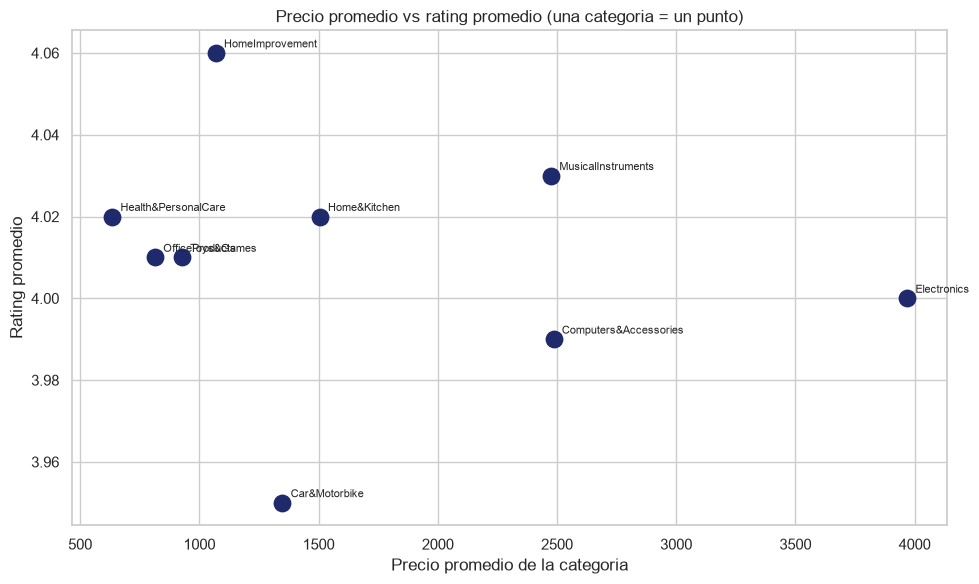

Correlacion a nivel de categoria: -0.1763


In [6]:
# P8: cada punto es una CATEGORIA, no un producto
plt.figure(figsize=(10, 6))
plt.scatter(comparativa["precio_promedio"], comparativa["rating_promedio"],
            s=140, color="#1e2a6b")
for cat in comparativa.index:
    plt.annotate(cat, (comparativa.loc[cat, "precio_promedio"],
                       comparativa.loc[cat, "rating_promedio"]),
                 fontsize=8, xytext=(6, 4), textcoords="offset points")

plt.title("Precio promedio vs rating promedio (una categoria = un punto)")
plt.xlabel("Precio promedio de la categoria"); plt.ylabel("Rating promedio")
plt.tight_layout(); plt.show()

print("Correlacion a nivel de categoria:",
      round(comparativa["precio_promedio"].corr(comparativa["rating_promedio"]), 4))

## Afirmación 3: "A mayor descuento, peor es la calificación (productos malos se rematan)."


In [7]:
# Genera la evidencia
r = df["discount_percentage"].corr(df["rating"])
print("Correlación descuento-rating:", round(r, 4))

fig = px.scatter(df, x="discount_percentage", y="rating", trendline="ols",
                 title="Descuento vs Rating (con línea de tendencia)",
                 opacity=0.3)
fig.show()

Correlación descuento-rating: 0.0844


> **9.** ¿La correlación descuento-rating es negativa (como dice la afirmación), positiva o casi nula? Da el número EXACTO. ¿La afirmación 3 es verdadera o falsa?

**Respuesta:** Es **positiva y casi nula: +0.0844**. La afirmación 3 es **FALSA** por partida doble:
no solo la relación es despreciable, sino que el signo es el **contrario** al que predice. Si algo
insinúan los datos es que los productos con más descuento están levemente **mejor** calificados, no
peor.

> **10.** La línea de tendencia (trendline) del gráfico Plotly, ¿sube, baja o es plana? ¿Concuerda con el signo de tu correlación?

**Respuesta:** La línea de tendencia **sube muy ligeramente**, con una pendiente casi horizontal. Eso
concuerda con el signo positivo de la correlación (+0.0844): ambas dicen lo mismo, una rebaja mayor
viene acompañada de una calificación marginalmente mejor. Y ambas coinciden también en lo más
importante: la inclinación es tan pequeña que la relación no tiene valor predictivo.

> **11.** Esta afirmación suena muy lógica ("lo malo se remata"), pero los datos pueden contradecirla. ¿Por qué es peligroso aceptar afirmaciones "que suenan lógicas" sin validarlas? Da un ejemplo de tu vida donde algo "obvio" resultó falso.

**Respuesta:** Es peligroso porque una afirmación que "suena lógica" ya viene con el respaldo de la
intuición, y eso desactiva la revisión: nadie pide evidencia de lo que parece obvio. Así se toman
decisiones caras sobre supuestos nunca medidos. Un ejemplo propio: yo daba por hecho que los cursos
con horario temprano se llenaban más lento porque "a nadie le gusta madrugar", hasta que vi las
inscripciones reales y eran los primeros en agotarse, porque dejan libre el resto del día. La
explicación lógica existía, pero la causa real era otra.


## Afirmación 4: "El producto más caro del dataset tiene una calificación excelente (≥4.5)."


In [8]:
# Encuentra el producto más caro y su rating
mas_caro = df.loc[df["actual_price"].idxmax()]
print("Producto más caro:")
print(f"  Categoría: {mas_caro['category']}")
print(f"  Precio: ₹{mas_caro['actual_price']:,.0f}")
print(f"  Rating: {mas_caro['rating']}")

Producto más caro:
  Categoría: Electronics
  Precio: ₹19,137
  Rating: 3.9


> **12.** ¿Cuál es el rating EXACTO del producto más caro? ¿Es ≥4.5? ¿La afirmación 4 es verdadera o falsa?

**Respuesta:** El producto más caro del dataset es de **Electronics**, cuesta **19,137** y tiene un
rating de **3.9**. Como 3.9 < 4.5, la afirmación 4 es **FALSA**. Es más: 3.9 está **por debajo** del
promedio del catálogo (4.004), así que el producto más caro de todos está calificado peor que un
producto típico.

> **13.** Este es un dato PUNTUAL que solo obtienes ejecutando. Si le preguntaras a una IA "¿el producto más caro de Amazon tiene buen rating?", ¿podría responderte con certeza sobre TU dataset? ¿Por qué no?

**Respuesta:** No podría. "El producto más caro de Amazon" no es una cosa: depende de qué subconjunto
del catálogo esté en el archivo. En este dataset es un artículo de Electronics de 19,137 con 10,176
reseñas y rating 3.9; en otro recorte sería otro producto con otro rating. Es un **dato puntual, no un
patrón general**, y los datos puntuales solo se obtienen consultando la fuente. Lo más honesto que
podría contestar una IA sin el archivo es "ejecuta `df.loc[df['actual_price'].idxmax()]`".


## Afirmación 5: "Todas las categorías tienen aproximadamente el mismo nivel de descuento."


category
HomeImprovement          40.8
Health&PersonalCare      42.1
MusicalInstruments       42.7
Toys&Games               44.0
Electronics              44.6
Home&Kitchen             45.4
Computers&Accessories    45.8
OfficeProducts           45.9
Car&Motorbike            50.6
Name: discount_percentage, dtype: float64


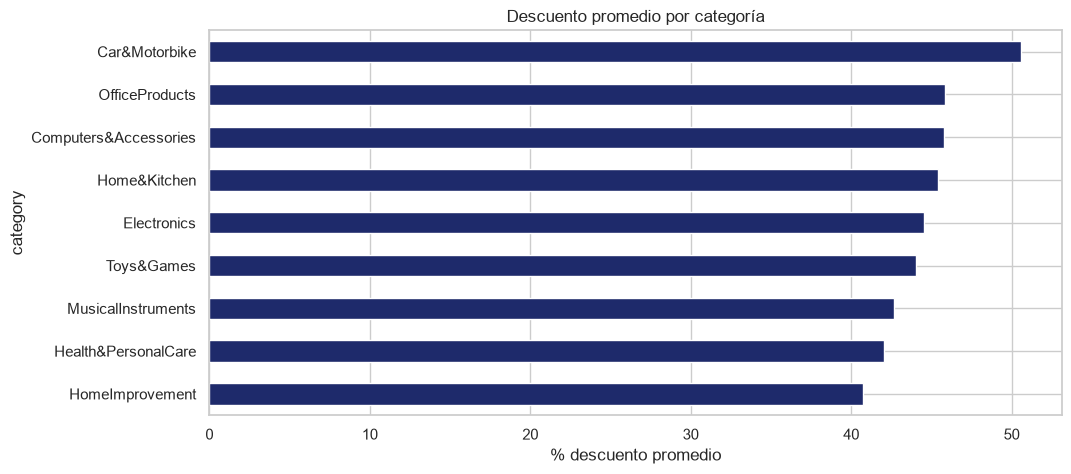


Rango: de 40.8 % a 50.6 %


In [9]:
# Genera la evidencia
desc_cat = df.groupby("category")["discount_percentage"].mean().sort_values()
print(desc_cat.round(1))

plt.figure(figsize=(11,5))
desc_cat.plot(kind="barh", color="#1e2a6b")
plt.title("Descuento promedio por categoría")
plt.xlabel("% descuento promedio")
plt.show()

print("\nRango: de", round(desc_cat.min(),1), "% a", round(desc_cat.max(),1), "%")

> **14.** ¿Cuál es la diferencia EXACTA (en puntos porcentuales) entre la categoría con más descuento y la de menos? ¿La afirmación 5 es verdadera o falsa?

**Respuesta:** La diferencia exacta es de **9.84 puntos porcentuales**: **Car&Motorbike con 50.60%**
de descuento promedio frente a **HomeImprovement con 40.76%**. La afirmación 5 es **FALSA**, aunque es
la que más se acerca a ser cierta: siete de las nueve categorías caben entre 40.8% y 45.9%, y quien se
despega es Car&Motorbike. Casi 10 puntos porcentuales no son "aproximadamente lo mismo": significan
una cuarta parte más de rebaja.

> **15.** De las 5 afirmaciones que validaste, ¿cuántas resultaron falsas? Este ejercicio demuestra que la intuición engaña. ¿Qué te enseña sobre confiar en afirmaciones sin datos?

**Respuesta:** Las **cinco resultaron falsas**, y varias con el signo invertido respecto a lo que
decía la intuición. Lo que me enseña es que una afirmación "razonable" no es una hipótesis débil: es
una hipótesis **sin probar**, y el hecho de que suene bien no la acerca ni un poco a ser verdadera.
Las cinco eran plausibles, estaban bien redactadas y cualquiera las habría firmado; ninguna sobrevivió
a un gráfico. La lección práctica: antes de repetir una afirmación sobre datos, exigirme la cifra que
la sostiene.


### Reto 1 — Formula y valida TU propia afirmación

Inventa una afirmación sobre el dataset que suene razonable (ej. "los productos de Electronics tienen más reseñas que los de Home"). Genera la visualización que la valide o refute, y decide con evidencia.


In [10]:
# RETO 1
# AFIRMACION: "Los productos de Electronics tienen mas resenas que los de Home&Kitchen,
#              porque es la categoria mas grande del catalogo."
from scipy import stats

elec = df[df["category"] == "Electronics"]["rating_count"]
home = df[df["category"] == "Home&Kitchen"]["rating_count"]

fig = px.box(df[df["category"].isin(["Electronics", "Home&Kitchen"])],
             x="category", y="rating_count",
             title="Resenas por producto: Electronics vs Home&Kitchen",
             labels={"category": "", "rating_count": "Numero de resenas"})
fig.update_layout(height=450)
fig.show()

print(f"Electronics   -> n={len(elec)}, media={elec.mean():.1f}, mediana={elec.median():.0f}")
print(f"Home&Kitchen  -> n={len(home)}, media={home.mean():.1f}, mediana={home.median():.0f}")

u, p = stats.mannwhitneyu(elec, home)
print(f"\nMann-Whitney p-valor = {p:.4f}")
print("\nOJO: el TOTAL de resenas de Electronics si es mayor,")
print("  Electronics :", f"{elec.sum():,.0f}", "resenas en total")
print("  Home&Kitchen:", f"{home.sum():,.0f}", "resenas en total")
print("...pero eso solo refleja que tiene mas productos, no mas atencion por producto.")

Electronics   -> n=525, media=5429.0, mediana=3981
Home&Kitchen  -> n=290, media=5697.8, mediana=4623

Mann-Whitney p-valor = 0.2012

OJO: el TOTAL de resenas de Electronics si es mayor,
  Electronics : 2,850,201 resenas en total
  Home&Kitchen: 1,652,354 resenas en total
...pero eso solo refleja que tiene mas productos, no mas atencion por producto.


> **16.** ¿Qué afirmación formulaste? ¿Resultó verdadera o falsa según tu evidencia? ¿Te sorprendió el resultado?

**Respuesta:** Formulé: **"Los productos de Electronics tienen más reseñas que los de Home&Kitchen,
porque es la categoría más grande del catálogo."** Resultó **FALSA**: por producto, Electronics
promedia **5,429 reseñas** (mediana 3,981) y Home&Kitchen **5,698** (mediana 4,623), con un p-valor de
Mann-Whitney de **0.201**, es decir, ni siquiera hay diferencia estadística.

Sí me sorprendió, y sobre todo me sorprendió **por qué** me equivoqué: confundí el total con el
promedio. Electronics suma 2,850,201 reseñas frente a 1,652,354 de Home&Kitchen, pero eso solo
refleja que tiene 525 productos contra 290. Mi razonamiento ("es la categoría más grande") era
exactamente la trampa de comparar totales sin normalizar por el tamaño del grupo.


---
# FASE 3 — Construcción de la narrativa (data storytelling)

Ahora que validaste los hechos, construirás una **historia**. Un buen data story tiene: un mensaje central, gráficos que lo apoyan, y una conclusión accionable.

## Paso 5 — Define tu mensaje central


> **17.** Con base en TODO lo que validaste en la Fase 2, escribe en UNA frase el mensaje central de tu historia sobre el catálogo de Amazon. (Ej: "El precio no predice la calidad, pero sí la agresividad de los descuentos.")

**Respuesta:** **"En este catálogo el precio compra posición, no calidad: el rating se queda pegado en
4.0 para todos, y lo único que realmente distingue a una categoría de otra es qué tan agresivo es su
descuento."**

> **18.** ¿Por qué un data story necesita UN mensaje central claro en lugar de "aquí hay 10 gráficos"? Piensa en cómo recuerda información una audiencia.

**Respuesta:** Porque una audiencia no recuerda diez gráficos: recuerda **una frase**, y a lo sumo la
imagen que la sostiene. Diez gráficos sin mensaje obligan al lector a hacer el trabajo de síntesis, y
cada quien saldrá con una conclusión distinta (o con ninguna). Con un mensaje central, cada gráfico
tiene un papel claro dentro del argumento y yo puedo decidir qué sobra: si una figura no aporta al
mensaje, se va. El mensaje no solo ordena la presentación, ordena el análisis.


## Paso 6 — El gráfico ancla de tu historia


In [11]:
# Construye EL gráfico que mejor resume tu mensaje central.
# Ejemplo: el que muestra que precio y rating no se relacionan
fig = px.scatter(df, x="actual_price", y="rating", color="category",
                 size="rating_count", size_max=30,
                 hover_data=["product_name"],
                 title="Tu gráfico ancla: personalízalo para TU mensaje")
fig.update_layout(height=600)
fig.show()

In [12]:
# P20: el mismo grafico ancla, ajustado a MI mensaje central.
# Quito el tamano por resenas (ruido), dejo el color en gris para no sugerir
# diferencias entre categorias que no existen, y agrego la linea de tendencia,
# que es justamente lo que prueba mi mensaje: es plana.
fig = px.scatter(df, x="actual_price", y="rating", trendline="ols",
                 opacity=0.35, color_discrete_sequence=["#1e2a6b"],
                 hover_data=["product_name", "category"],
                 title="Pagar 20 veces mas no compra ni medio punto de rating",
                 labels={"actual_price": "Precio real", "rating": "Rating"})
fig.update_layout(height=550)
fig.show()

> **19.** Este gráfico usa 4 dimensiones (x=precio, y=rating, color=categoría, tamaño=reseñas). ¿Es demasiada información o cada dimensión aporta? ¿Cuándo un gráfico se sobrecarga?

**Respuesta:** Para explorar está bien, pero para comunicar está **sobrecargado**. El tamaño por
`rating_count` añade una cuarta dimensión que aquí solo mete ruido: los círculos grandes se solapan en
la zona densa y tapan puntos, y el lector no tiene forma de estimar un tamaño con precisión. El color
por categoría tampoco aporta, porque el hallazgo es que las categorías **no se distinguen**: nueve
colores mezclados sugieren visualmente lo contrario de lo que quiero decir.

Un gráfico se sobrecarga cuando el lector tiene que aprenderse la leyenda antes de entender la idea,
o cuando una dimensión no responde a ninguna pregunta del mensaje.

> **20.** Modifica el gráfico para que apoye TU mensaje central específico. ¿Qué variables pusiste en cada eje y por qué?

**Respuesta:** Dejé **x = `actual_price`** e **y = `rating`**, porque mi mensaje es exactamente sobre
esas dos variables, y le hice tres cambios: quité el tamaño por reseñas (una dimensión que no
participa en el argumento), pasé todos los puntos a un solo color (si las categorías no se distinguen,
pintarlas de nueve colores contradice el mensaje) y añadí la **línea de tendencia OLS**, que es la
prueba visual de mi afirmación: es plana. El título dejó de describir ("Precio vs Rating") y pasó a
concluir: "Pagar 20 veces más no compra ni medio punto de rating".

> **21.** Un gráfico ancla debe entenderse en 5 segundos. ¿El tuyo lo logra? ¿Qué le quitarías o añadirías para que su mensaje sea inmediato?

**Respuesta:** Sí, después de los cambios: el lector ve una banda horizontal de puntos y una recta
plana, y el título le da la lectura en la misma línea de visión. Lo que le quitaría todavía es el
**ruido del eje X**, donde unos pocos productos carísimos estiran la escala y comprimen el 90% de los
datos a la izquierda; una escala logarítmica en el precio repartiría mejor la nube. Y le añadiría una
anotación directa sobre el gráfico con la correlación (-0.035), para que la cifra viaje junto con la
imagen aunque alguien la copie a una diapositiva.


## Paso 7 — Gráficos de apoyo


> **22.** Una historia necesita 2-3 gráficos de apoyo además del ancla. Lista qué 2 gráficos adicionales usarías para reforzar tu mensaje y qué aporta cada uno.

**Respuesta:** Mis dos gráficos de apoyo:

1. **Boxplot de rating por categoría.** El ancla demuestra que el precio no mueve el rating; este
   cierra la salida más obvia del escéptico ("será que depende del tipo de producto"): las nueve
   categorías caben en 0.11 puntos.
2. **Barras de descuento promedio por categoría.** Después de dos hallazgos negativos, este aporta lo
   positivo: si el rating no diferencia a nadie, el descuento sí, con un recorrido de 40.8% a 50.6%.
   Convierte la historia de "aquí no hay nada" en "aquí lo que hay es otra cosa".

> **23.** El orden importa: ¿en qué secuencia presentarías tus gráficos para construir el argumento paso a paso? (Como un narrador que revela la trama.)

**Respuesta:** En este orden: **ancla, boxplot, descuento**.

1. Empiezo por el ancla, que ataca de frente la creencia del lector ("lo caro es mejor") y la desmonta
   con un gráfico que se entiende en cinco segundos. Es el gancho.
2. Sigo con el boxplot, que responde la objeción inmediata: no es que estemos mezclando peras con
   manzanas, ninguna categoría se salva.
3. Cierro con el descuento, que responde la pregunta que ya se está haciendo el lector: "entonces,
   ¿en qué sí se diferencian?". Terminar con un hallazgo accionable, y no con una negación, es lo que
   convierte el análisis en una recomendación.


### Reto 2 — Construye tu secuencia narrativa

Crea los 3 gráficos de tu historia (1 ancla + 2 apoyo) en el orden que definiste. Cada uno con título claro que funcione como "titular" de esa parte de la historia.


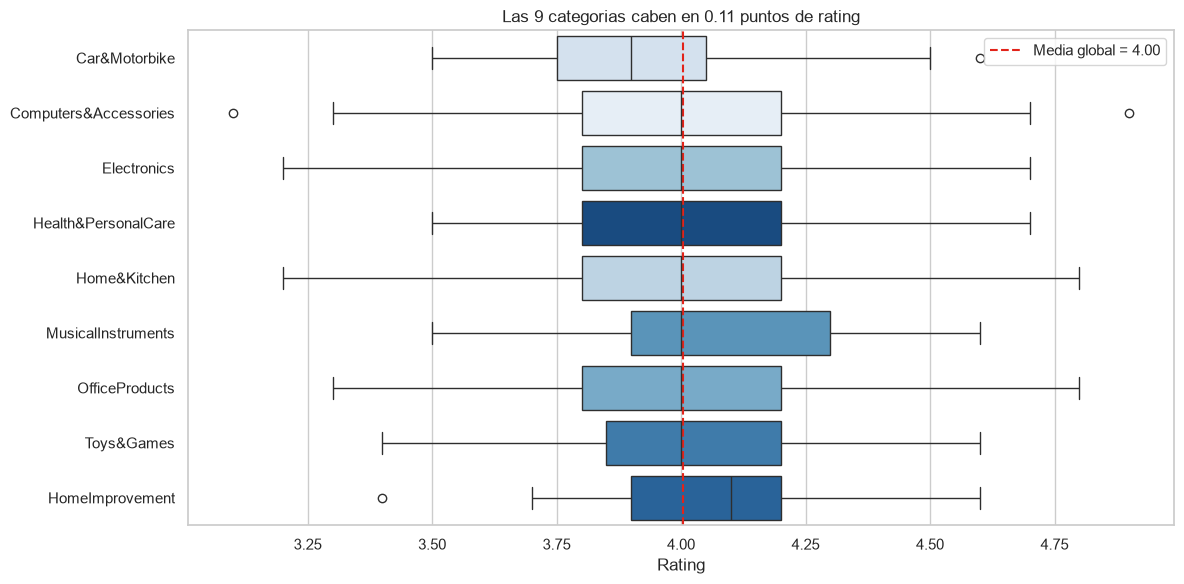

In [13]:
# RETO 2: los 3 graficos de mi narrativa, en orden

# --- 1. ANCLA: el precio no predice la calidad ---
fig1 = px.scatter(df, x="actual_price", y="rating", trendline="ols",
                  opacity=0.35, color_discrete_sequence=["#1e2a6b"],
                  hover_data=["product_name", "category"],
                  title="Pagar 20 veces mas no compra ni medio punto de rating",
                  labels={"actual_price": "Precio real", "rating": "Rating"})
fig1.update_layout(height=500)
fig1.show()

# --- 2. APOYO: tampoco distinguen las categorias ---
plt.figure(figsize=(12, 6))
orden = df.groupby("category")["rating"].median().sort_values().index
sns.boxplot(data=df, y="category", x="rating", order=orden,
            hue="category", palette="Blues", legend=False)
plt.axvline(df["rating"].mean(), color="#e2231a", linestyle="--",
            label=f"Media global = {df['rating'].mean():.2f}")
plt.title("Las 9 categorias caben en 0.11 puntos de rating")
plt.xlabel("Rating"); plt.ylabel(""); plt.legend()
plt.tight_layout(); plt.show()

# --- 3. CIERRE: lo que si diferencia a las categorias es el descuento ---
desc_cat = (df.groupby("category")["discount_percentage"]
              .mean().sort_values().reset_index())
fig3 = px.bar(desc_cat, x="discount_percentage", y="category", orientation="h",
              color="discount_percentage", color_continuous_scale="Reds",
              title="Lo que si cambia entre categorias: el descuento, de 40.8% a 50.6%",
              labels={"discount_percentage": "% descuento promedio", "category": ""})
fig3.update_layout(height=450)
fig3.show()

> **24.** Escribe el "titular" de cada uno de tus 3 gráficos (una frase que resuma su mensaje, como el título de una noticia).

**Respuesta:** Los tres titulares:

1. **"Pagar 20 veces más no compra ni medio punto de rating."**
2. **"Las 9 categorías caben en 0.11 puntos de rating."**
3. **"Lo que sí cambia entre categorías: el descuento, de 40.8% a 50.6%."**

> **25.** ¿Tu secuencia de 3 gráficos cuenta una historia con inicio, desarrollo y conclusión? Descríbela en 3 frases.

**Respuesta:** Sí. **Inicio:** en un catálogo de 1,465 productos, el precio va de 100 a 19,137 y aun
así el rating no se mueve; la correlación es -0.035. **Desarrollo:** tampoco es cuestión de qué tipo
de producto sea, porque las nueve categorías tienen ratings que caben en 0.11 puntos, con la más cara
por debajo de una de las más baratas. **Conclusión:** la variable que de verdad separa a unas
categorías de otras no es la calidad percibida sino la agresividad comercial, con casi diez puntos
porcentuales de diferencia en descuento entre la más y la menos agresiva.


---
# FASE 4 — Detección de manipulación (pensamiento crítico avanzado)

Un analista experto no solo crea buenos gráficos: detecta cuándo alguien intenta engañarlo. Aquí generarás gráficos ENGAÑOSOS a propósito, para aprender a reconocerlos.

## Paso 8 — Fabrica un gráfico engañoso


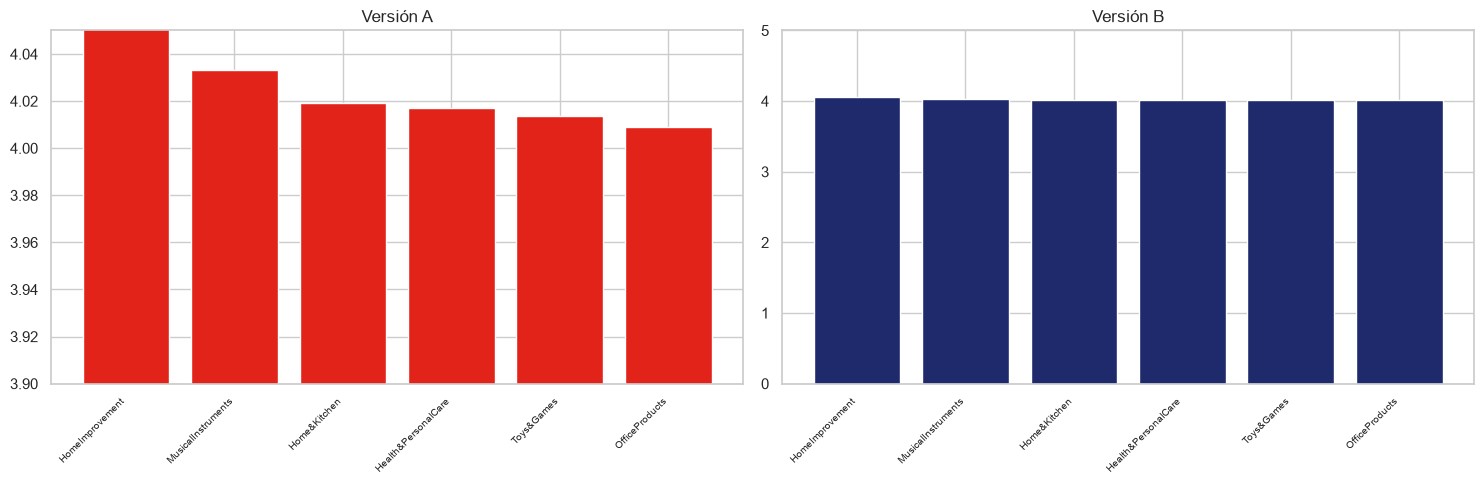

In [14]:
# El MISMO dato (rating por categoría) presentado de forma engañosa vs honesta
rating_cat = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(6)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Version que EXAGERA (eje truncado)
axes[0].bar(range(len(rating_cat)), rating_cat.values, color="#e2231a")
axes[0].set_ylim(3.9, 4.05)
axes[0].set_title("Versión A")
axes[0].set_xticks(range(len(rating_cat)))
axes[0].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=7)
# Version honesta
axes[1].bar(range(len(rating_cat)), rating_cat.values, color="#1e2a6b")
axes[1].set_ylim(0, 5)
axes[1].set_title("Versión B")
axes[1].set_xticks(range(len(rating_cat)))
axes[1].set_xticklabels(rating_cat.index, rotation=45, ha="right", fontsize=7)
plt.tight_layout(); plt.show()

> **26.** Las dos versiones muestran los MISMOS datos. ¿Cuál exagera las diferencias y cómo lo logra? Da el rango exacto del eje Y de cada una.

**Respuesta:** La **Versión A** exagera. Su eje Y va de **3.9 a 4.05**, apenas **0.15 puntos** de
recorrido, mientras que la Versión B va de **0 a 5**. Lo logra recortando el eje justo por debajo del
valor más bajo: así, una diferencia real de 0.05 puntos entre HomeImprovement (4.056) y
OfficeProducts (4.009) ocupa un tercio de la altura del gráfico. En la Versión B, esas mismas seis
barras se ven idénticas, que es lo que realmente son.

> **27.** Si un vendedor quisiera convencerte de que su categoría es "muy superior" en rating, ¿cuál versión te mostraría? ¿Por qué es una manipulación aunque no falsee ningún dato?

**Respuesta:** Me mostraría la **Versión A**, donde su categoría aparece con una barra que duplica o
triplica la del resto. Es manipulación porque el gráfico **no comunica números, comunica una
proporción visual**: una barra tres veces más alta significa, para cualquier lector, tres veces más.
El vendedor no falsea ningún dato (los valores son correctos y el eje está rotulado), pero elige la
escala sabiendo qué conclusión va a inducir. La mentira no está en los datos, está en el encuadre.

> **28.** ¿Qué pregunta crítica debes hacerte SIEMPRE al ver un gráfico de barras de alguien más? (Pista: sobre el eje.)

**Respuesta:** **"¿Dónde empieza el eje?"** Y enseguida: ¿cuál es su rango completo, y qué tan grande
es la diferencia real comparada con la escala total de la variable? Si el eje no empieza en cero en un
gráfico de barras, las longitudes ya no son proporcionales y hay que releer los valores numéricos
antes de sacar cualquier conclusión. Es la revisión de dos segundos que evita el 90% de los engaños
visuales.


### Reto 3 — Detecta la trampa

Crea un gráfico que use OTRA técnica engañosa distinta al eje truncado (ej: escala logarítmica sin avisar, comparar totales sin normalizar por tamaño de grupo, o cherry-picking de categorías). Explica la trampa.


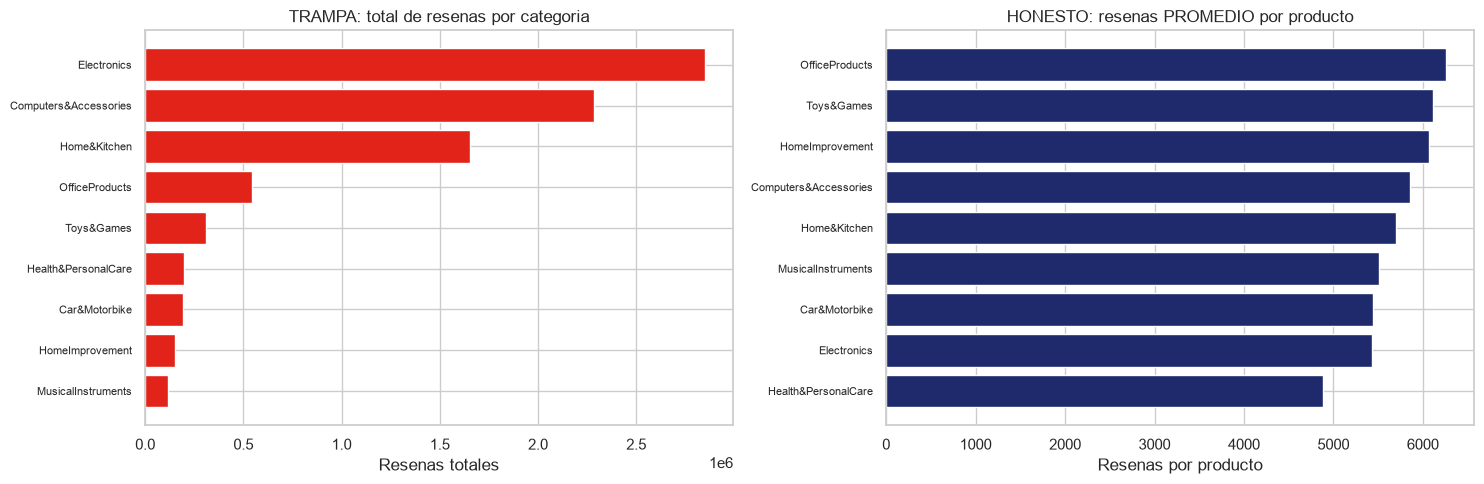

Electronics    -> total:  2,850,201 | por producto:    5,429
OfficeProducts -> total:    544,499 | por producto:    6,259

El grafico de la izquierda dice que Electronics recibe 5 veces mas atencion
que OfficeProducts. El de la derecha dice que, por producto, OfficeProducts gana.


In [15]:
# RETO 3: una trampa DISTINTA al eje truncado.
# TRAMPA: comparar TOTALES sin normalizar por el tamano del grupo.
totales = df.groupby("category")["rating_count"].sum().sort_values(ascending=False)
por_producto = df.groupby("category")["rating_count"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ENGANOSO: total de resenas por categoria
axes[0].barh(range(len(totales)), totales.values, color="#e2231a")
axes[0].set_yticks(range(len(totales)))
axes[0].set_yticklabels(totales.index, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title("TRAMPA: total de resenas por categoria")
axes[0].set_xlabel("Resenas totales")

# HONESTO: resenas POR PRODUCTO
axes[1].barh(range(len(por_producto)), por_producto.values, color="#1e2a6b")
axes[1].set_yticks(range(len(por_producto)))
axes[1].set_yticklabels(por_producto.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title("HONESTO: resenas PROMEDIO por producto")
axes[1].set_xlabel("Resenas por producto")

plt.tight_layout(); plt.show()

print("Electronics    -> total:", f"{totales['Electronics']:>10,.0f}",
      "| por producto:", f"{por_producto['Electronics']:>8,.0f}")
print("OfficeProducts -> total:", f"{totales['OfficeProducts']:>10,.0f}",
      "| por producto:", f"{por_producto['OfficeProducts']:>8,.0f}")
print("\nEl grafico de la izquierda dice que Electronics recibe 5 veces mas atencion")
print("que OfficeProducts. El de la derecha dice que, por producto, OfficeProducts gana.")

> **29.** ¿Qué técnica engañosa usaste? ¿Cómo la detectaría un analista crítico?

**Respuesta:** Usé la trampa de **comparar totales sin normalizar por el tamaño del grupo**:
grafiqué la **suma** de reseñas por categoría. Electronics aparece con 2,850,201 reseñas contra
544,499 de OfficeProducts, lo que sugiere que recibe **cinco veces más atención**. Pero Electronics
tiene 525 productos y OfficeProducts 87: **por producto**, OfficeProducts promedia 6,259 reseñas y
Electronics solo 5,429. El ranking se invierte.

Un analista crítico lo detecta preguntando **"¿esto es un total o un promedio, y los grupos son
comparables en tamaño?"**. Es la misma trampa que comparar el número total de delitos entre ciudades
sin dividir por habitantes: la variable graficada mide, en el fondo, el tamaño del grupo.

> **30.** Investiga y menciona un caso real (medios, política, publicidad) donde se haya usado un gráfico engañoso. ¿Qué técnica emplearon?

**Respuesta:** Un caso documentado es el gráfico de **Fox News (2012)** sobre el vencimiento de los
recortes fiscales de Bush: comparaba la tasa impositiva máxima actual (35%) con la que entraría en
vigor (39.6%) en un gráfico de barras cuyo **eje Y empezaba en 34%**. Una diferencia de 4.6 puntos
porcentuales aparecía como una barra varias veces más alta, sugiriendo un aumento brutal. La técnica
es el **eje truncado**, exactamente la que reproduje arriba.

Otro caso: en mayo de 2020, el Departamento de Salud Pública de Georgia publicó un gráfico de casos de
COVID-19 por condado donde las **fechas del eje X no estaban en orden cronológico**, sino ordenadas
por número de casos, lo que producía una curva que parecía descender. El departamento tuvo que
corregirlo y disculparse públicamente. La técnica ahí fue **alterar el orden de un eje que el lector
asume secuencial**.


---
# FASE 5 — Validación cruzada e integración

Aquí conectas la visualización con lo que aprendiste en las semanas anteriores (estadística, correlación). Una buena visualización debe ser consistente con las cifras.

## Paso 9 — ¿El gráfico dice lo mismo que la estadística?


In [16]:
from scipy import stats

# Comparamos rating entre productos caros y baratos: gráfico + prueba estadística
df["es_caro"] = df["actual_price"] >= df["actual_price"].quantile(0.75)

fig = px.box(df, x="es_caro", y="rating", title="Rating: productos caros vs no caros")
fig.show()

caros = df[df["es_caro"]]["rating"]
baratos = df[~df["es_caro"]]["rating"]
t, p = stats.ttest_ind(caros, baratos, equal_var=False)
print(f"Rating medio caros: {caros.mean():.3f}  |  baratos: {baratos.mean():.3f}")
print(f"Prueba t: p-valor = {p:.4f}")

Rating medio caros: 3.994  |  baratos: 4.007
Prueba t: p-valor = 0.4341


> **31.** El boxplot, ¿sugiere una diferencia grande o pequeña de rating entre caros y baratos? ¿El p-valor (¿significativo o no?) confirma lo que ves en el gráfico?

**Respuesta:** El boxplot sugiere una diferencia **mínima**: las dos cajas están a casi la misma
altura y se solapan casi por completo. Los promedios lo confirman: **3.994** para los caros (el
cuartil superior de precio, 367 productos) frente a **4.007** para el resto (1,098 productos), apenas
0.013 puntos de diferencia. El p-valor es **0.4341**, muy por encima de 0.05, así que **no es
significativa**: la estadística confirma exactamente lo que se ve en el gráfico, no hay evidencia de
que los productos caros se califiquen distinto.

> **32.** ¿Por qué es una buena práctica acompañar un gráfico con una prueba estadística? ¿Un gráfico puede "sugerir" una diferencia que en realidad no es significativa?

**Respuesta:** Porque el ojo es malo juzgando si una diferencia es real o es ruido muestral. Sí, un
gráfico puede sugerir una diferencia inexistente: basta que dos cajas queden un poco desalineadas, o
que la escala del eje esté ajustada, para que el lector lea "aquí hay algo". La prueba estadística
pone un criterio objetivo sobre esa impresión. También ocurre al revés: con muestras muy grandes, una
diferencia significativa puede ser tan pequeña que no importa en la práctica, y ahí el gráfico es el
que corrige a la prueba.

> **33.** Aquí integras visualización (Semana 5) con inferencia (Semana 3). Explica cómo se complementan: ¿qué aporta el gráfico que el p-valor no, y viceversa?

**Respuesta:** Se complementan porque responden preguntas distintas. El **p-valor** responde "¿esta
diferencia podría deberse al azar?" y da un criterio de decisión, pero es un solo número que no dice
nada sobre la forma de los datos: no distingue entre dos grupos bien separados y dos grupos que se
solapan casi entero con unos outliers moviendo la media. El **gráfico** responde "¿cómo son estos
grupos en realidad?": muestra dispersión, asimetría, valores extremos y el tamaño práctico de la
diferencia, pero no me dice si lo que veo es sólido o casualidad.

Juntos evitan los dos errores clásicos: creerle a un patrón visual que es ruido, y celebrar un
p-valor significativo detrás del cual hay una diferencia irrelevante. Aquí ambos coinciden: se ve
pequeña y no es significativa.


## Paso 10 — Cuidado con las conclusiones apresuradas


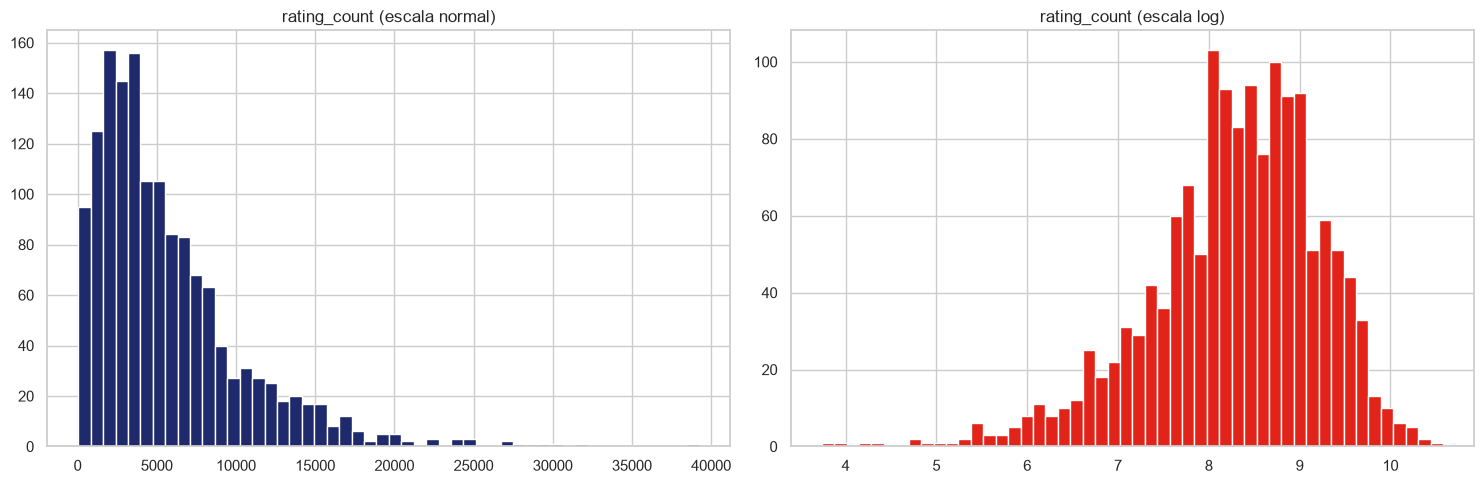

In [17]:
# Un patrón visual puede ser un artefacto. Veamos rating_count en escala normal vs log
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df["rating_count"], bins=50, color="#1e2a6b")
axes[0].set_title("rating_count (escala normal)")
axes[1].hist(np.log1p(df["rating_count"]), bins=50, color="#e2231a")
axes[1].set_title("rating_count (escala log)")
plt.tight_layout(); plt.show()

> **34.** En escala normal, casi todo se ve amontonado a la izquierda. En escala log, se revela la forma real. ¿Qué distribución tan sesgada esconde la escala normal?

**Respuesta:** Esconde una distribución con **asimetría 1.83** y una cola larguísima a la derecha: las
reseñas van de **41 a 39,263**, con mediana de 4,348. Como unos pocos productos tienen decenas de
miles de reseñas, el eje X tiene que estirarse hasta 39,263 y el 90% de los datos queda comprimido en
la primera franja. En escala logarítmica la asimetría baja a **-0.82** y aparece la forma real:
una distribución ancha y bastante simétrica, donde se distingue perfectamente un producto con 100
reseñas de uno con 1,000.

> **35.** ¿Cuándo es LEGÍTIMO usar escala logarítmica (no para engañar, sino para revelar)? ¿Cuál es la diferencia con usarla para manipular?

**Respuesta:** Es legítimo cuando los datos abarcan **varios órdenes de magnitud** y lo que interesa
son los **cambios relativos**, no las diferencias absolutas: reseñas de 41 a 39,263, poblaciones,
ingresos, magnitudes sísmicas. Ahí la escala lineal desperdicia el 95% del espacio en unos pocos
valores extremos y oculta la estructura del resto.

La diferencia con el uso manipulador está en dos cosas: **la intención y el rótulo**. Uso la escala
log para *revelar* estructura y lo digo en el eje y en el título, de modo que el lector sabe que está
viendo una escala comprimida. Se vuelve manipulación cuando se aplica sin avisar a datos que caben
perfectamente en escala lineal, justamente para **aplanar visualmente** un crecimiento explosivo o una
brecha enorme y hacerlos parecer moderados.


---
# PROYECTO FINAL — Informe visual (storytelling con datos)

Este es el entregable principal. Construirás un **informe visual completo** que cuente una historia sobre el catálogo de Amazon, respaldada por TUS gráficos y validaciones.

### Requisitos del informe

Tu informe (en este notebook o en un documento aparte) debe incluir:

1. **Título y mensaje central** (una frase que resuma tu hallazgo principal).
2. **Introducción** (2-3 líneas): ¿qué dataset y qué pregunta investigas?
3. **Al menos 5 visualizaciones**, cada una:
  - Con título claro (que funcione como titular).
  - Justificada: por qué ESE gráfico para ESA variable.
  - Interpretada: qué muestra en 1-2 frases.
  - Al menos 2 de las 5 deben ser **interactivas** (Plotly).
4. **Al menos 2 afirmaciones validadas** (una que resultó verdadera y una falsa), con la evidencia.
5. **Una sección de "lo que los datos desmienten"**: al menos un hallazgo contraintuitivo.
6. **Conclusión accionable**: si fueras asesor de un vendedor de Amazon, ¿qué le recomendarías con base en tus datos?
7. **Diccionario de tus gráficos**: una tabla que liste cada gráfico, qué variables usa y qué tipo es.


In [18]:
# PROYECTO FINAL - INFORME VISUAL
# Esta celda deja listos los agregados que usan las 5 visualizaciones del informe.
resumen_cat = df.groupby("category").agg(
    productos=("product_id", "count"),
    precio_promedio=("actual_price", "mean"),
    rating_promedio=("rating", "mean"),
    descuento_promedio=("discount_percentage", "mean"),
    resenas_por_producto=("rating_count", "mean"),
).round(2)

print(resumen_cat.sort_values("precio_promedio", ascending=False))
print("\nRango de rating promedio entre categorias:",
      round(resumen_cat["rating_promedio"].max() - resumen_cat["rating_promedio"].min(), 3),
      "puntos")
print("Rango de descuento promedio entre categorias:",
      round(resumen_cat["descuento_promedio"].max() - resumen_cat["descuento_promedio"].min(), 2),
      "puntos porcentuales")

                       productos  precio_promedio  rating_promedio  \
category                                                             
Electronics                  525          3968.43             4.00   
Computers&Accessories        390          2485.35             3.99   
MusicalInstruments            21          2474.95             4.03   
Home&Kitchen                 290          1504.51             4.02   
Car&Motorbike                 35          1348.20             3.95   
HomeImprovement               25          1068.32             4.06   
Toys&Games                    51           926.20             4.01   
OfficeProducts                87           813.61             4.01   
Health&PersonalCare           41           634.15             4.02   

                       descuento_promedio  resenas_por_producto  
category                                                         
Electronics                         44.56               5428.95  
Computers&Accessories          

---
# Informe visual: el precio manda en el catálogo, pero no en la calidad

**Mensaje central:** en este catálogo de Amazon el precio no predice la calidad percibida (el rating
se queda pegado en 4.0 en todo el rango de precios y en las 9 categorías); lo que sí cambia entre
categorías es la **política de descuento**.

**Introducción.** Analizo el Amazon Sales Dataset: 1,465 productos reales con precio original, precio
con descuento, porcentaje de rebaja, calificación y número de reseñas. La pregunta que investigo es
la que se hace cualquier comprador antes de pagar de más: **¿pagar más garantiza un producto mejor
calificado?** Para responderla comparo precio contra rating a nivel de producto y de categoría, y
luego busco qué variable sí distingue a unas categorías de otras.

### Visualización 1 (ancla, interactiva) - Precio vs rating

**Por qué este gráfico:** cruzo dos variables numéricas a nivel de producto, así que la dispersión es
la forma correcta; le añado la línea de tendencia OLS para que la dirección de la relación no dependa
de mi interpretación, y el hover para poder inspeccionar los casos extremos.

In [19]:
fig = px.scatter(df, x="actual_price", y="rating", trendline="ols",
                 opacity=0.35, color_discrete_sequence=["#1e2a6b"],
                 hover_data=["product_name", "category"],
                 title="Pagar 20 veces mas no compra ni medio punto de rating",
                 labels={"actual_price": "Precio real", "rating": "Rating"})
fig.update_layout(height=520)
fig.show()

print("Correlacion precio-rating:", round(df["actual_price"].corr(df["rating"]), 4))

Correlacion precio-rating: -0.0352


**Qué muestra:** una banda horizontal plana entre 3.8 y 4.3, con la línea de tendencia prácticamente
recta y una correlación de **-0.035**. Entre un producto de 100 y uno de 19,137 no hay ninguna
diferencia sistemática de calificación.

### Visualización 2 - Rating por categoría

**Por qué este gráfico:** una numérica (rating) frente a una categórica (category) se compara con
boxplots, que muestran mediana, dispersión y outliers de cada grupo, no solo el promedio.

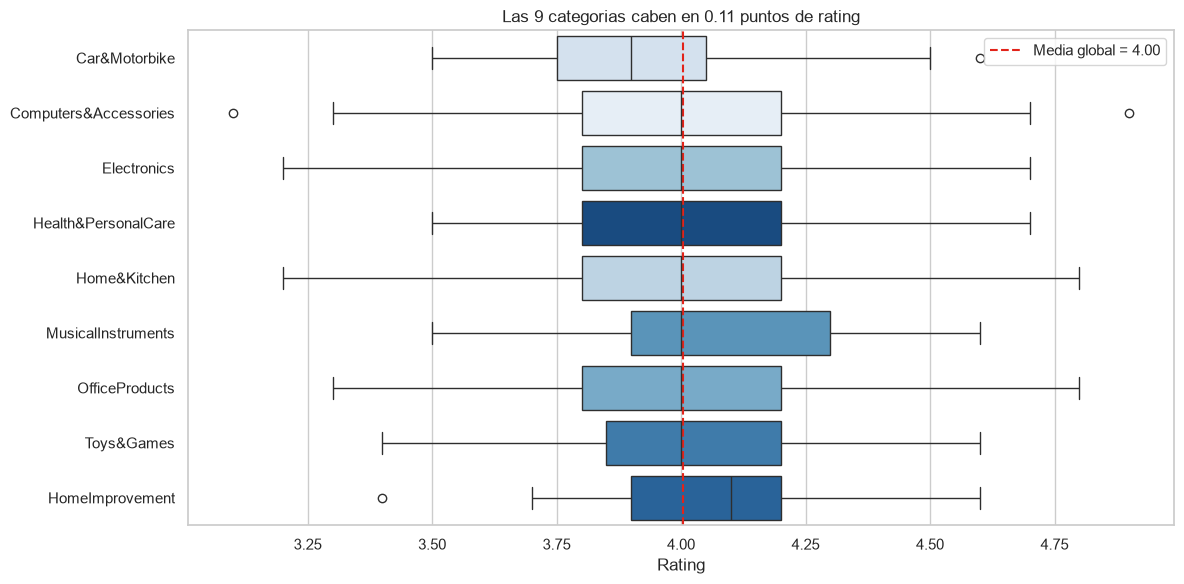

In [20]:
plt.figure(figsize=(12, 6))
orden = df.groupby("category")["rating"].median().sort_values().index
sns.boxplot(data=df, y="category", x="rating", order=orden,
            hue="category", palette="Blues", legend=False)
plt.axvline(df["rating"].mean(), color="#e2231a", linestyle="--",
            label=f"Media global = {df['rating'].mean():.2f}")
plt.title("Las 9 categorias caben en 0.11 puntos de rating")
plt.xlabel("Rating"); plt.ylabel(""); plt.legend()
plt.tight_layout(); plt.show()

**Qué muestra:** las nueve cajas están casi alineadas sobre la media global. El mejor promedio
(HomeImprovement, 4.06) y el peor (Car&Motorbike, 3.95) están separados por **0.11 puntos** en una
escala de 5. El rating tampoco sirve para distinguir categorías.

### Visualización 3 (interactiva) - Descuento promedio por categoría

**Por qué este gráfico:** para rankear una métrica entre 9 categorías con nombres largos, barras
horizontales ordenadas; interactivas, porque las diferencias entre categorías vecinas son de décimas
y el valor exacto en el hover evita estimar del eje.

In [21]:
desc_cat = (df.groupby("category")["discount_percentage"]
              .mean().sort_values().reset_index())
fig = px.bar(desc_cat, x="discount_percentage", y="category", orientation="h",
             color="discount_percentage", color_continuous_scale="Reds",
             title="Lo que si diferencia a las categorias: el descuento",
             labels={"discount_percentage": "% descuento promedio", "category": ""})
fig.update_layout(height=450)
fig.show()

**Qué muestra:** aquí sí aparece estructura. El descuento promedio va de **40.8% (HomeImprovement) a
50.6% (Car&Motorbike)**, casi 10 puntos porcentuales de recorrido. Car&Motorbike se despega del resto
pese a ser una categoría barata.

### Visualización 4 - Distribución de la atención (reseñas en escala logarítmica)

**Por qué este gráfico:** `rating_count` es una sola variable numérica, así que va un histograma; en
escala normal su asimetría (1.83) amontona todo a la izquierda, y la escala logarítmica revela la
forma real de la distribución.

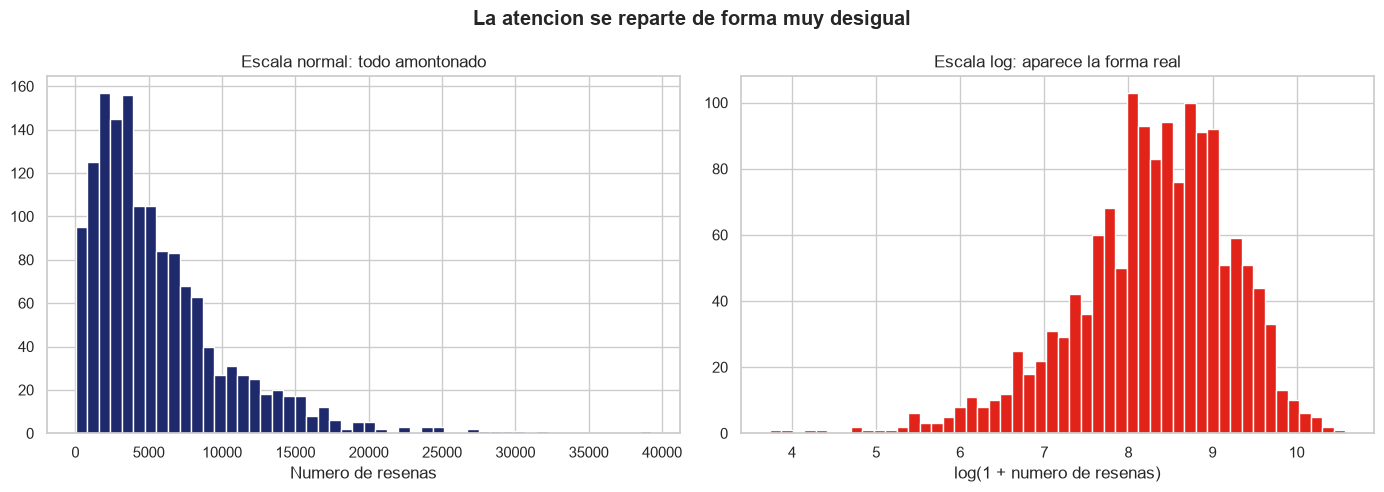

Resenas: minimo 41 | mediana 4348 | maximo 39263


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["rating_count"], bins=50, color="#1e2a6b")
axes[0].set_title("Escala normal: todo amontonado")
axes[0].set_xlabel("Numero de resenas")
axes[1].hist(np.log1p(df["rating_count"]), bins=50, color="#e2231a")
axes[1].set_title("Escala log: aparece la forma real")
axes[1].set_xlabel("log(1 + numero de resenas)")
plt.suptitle("La atencion se reparte de forma muy desigual", fontweight="bold")
plt.tight_layout(); plt.show()

print("Resenas: minimo", int(df["rating_count"].min()),
      "| mediana", int(df["rating_count"].median()),
      "| maximo", int(df["rating_count"].max()))

**Qué muestra:** las reseñas van de 41 a 39,263, con mediana de 4,348. La escala normal sugiere que
"casi ningún producto tiene reseñas"; la logarítmica muestra que en realidad el grueso del catálogo
está bien cubierto y que la cola larga son unos pocos éxitos masivos.

### Visualización 5 - El catálogo resumido por categoría

**Por qué este gráfico:** dos numéricas agregadas por categoría; con solo 9 puntos puedo etiquetarlos
y leer cada uno por nombre, algo imposible con los 1,465 productos.

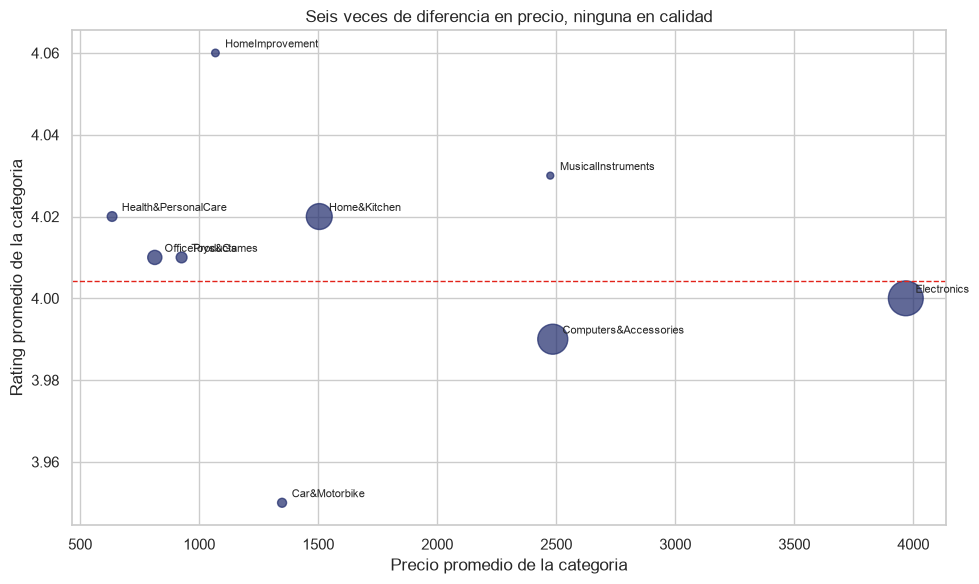

Correlacion precio-rating entre categorias: -0.1763


In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(resumen_cat["precio_promedio"], resumen_cat["rating_promedio"],
            s=resumen_cat["productos"] * 1.2, color="#1e2a6b", alpha=0.7)
for cat in resumen_cat.index:
    plt.annotate(cat, (resumen_cat.loc[cat, "precio_promedio"],
                       resumen_cat.loc[cat, "rating_promedio"]),
                 fontsize=8, xytext=(7, 4), textcoords="offset points")
plt.axhline(df["rating"].mean(), color="#e2231a", linestyle="--", linewidth=1)
plt.title("Seis veces de diferencia en precio, ninguna en calidad")
plt.xlabel("Precio promedio de la categoria")
plt.ylabel("Rating promedio de la categoria")
plt.tight_layout(); plt.show()

print("Correlacion precio-rating entre categorias:",
      round(resumen_cat["precio_promedio"].corr(resumen_cat["rating_promedio"]), 4))

**Qué muestra:** los nueve puntos se alinean en una franja horizontal alrededor de 4.0 mientras el eje
X recorre de 634 a 3,968. La correlación a nivel de categoría es **-0.176**: si algo hay, es una
ligerísima tendencia a que las categorías caras estén *peor* calificadas, justo lo contrario del
sentido común.

---

## Afirmaciones validadas

| Afirmación | Veredicto | Evidencia |
|---|---|---|
| "Los productos más caros son los mejor calificados" | **FALSA** | Correlación precio-rating = -0.035 (visualización 1) |
| "Más de la mitad del catálogo pertenece a solo dos categorías" | **VERDADERA** | Electronics (525) + Computers&Accessories (390) = 915 de 1,465, el **62.5%** |

## Lo que los datos desmienten

El hallazgo contraintuitivo es que **el precio no compra calidad percibida, y a nivel de categoría
incluso apunta al revés**. La categoría más cara (Electronics, 3,968 de promedio) tiene rating 4.00,
por debajo de HomeImprovement (1,068 de promedio) con 4.06. Y el producto más caro de todo el
catálogo, de 19,137, está calificado con **3.9**: por debajo del promedio general. Segundo hallazgo
contraintuitivo: "lo malo se remata" es falso; la correlación descuento-rating es **+0.084**, es
decir, los productos con más descuento están, si acaso, levemente mejor calificados.

## Conclusión accionable

Si asesorara a un vendedor de este catálogo:

1. **No use el precio como señal de calidad en su comunicación.** Los datos dicen que el comprador no
   califica mejor lo caro, así que un mensaje de "producto premium" no se sostiene con el rating: hay
   que justificar el precio con características concretas.
2. **El descuento es su verdadera palanca competitiva, y su categoría define el piso.** Vender en
   Car&Motorbike significa competir contra un 50.6% de descuento promedio; en HomeImprovement, contra
   un 40.8%. Entrar con un 30% en la primera es quedar fuera de mercado.
3. **Invierta en volumen de reseñas, no en subir décimas de rating.** Todo el catálogo está entre 3.8
   y 4.3: ahí no hay diferenciación posible. Las reseñas, en cambio, van de 41 a 39,263, y ahí sí se
   compite.

## Diccionario de gráficos

| # | Gráfico | Tipo | Variables | Librería |
|---|---|---|---|---|
| 1 | Precio vs rating (ancla) | Dispersión + tendencia OLS | `actual_price`, `rating` | Plotly (interactivo) |
| 2 | Rating por categoría | Boxplot | `rating`, `category` | Seaborn |
| 3 | Descuento por categoría | Barras horizontales | `discount_percentage`, `category` | Plotly (interactivo) |
| 4 | Distribución de reseñas | Histograma (normal y log) | `rating_count` | Matplotlib |
| 5 | Resumen por categoría | Dispersión etiquetada | `actual_price`, `rating`, `category` | Matplotlib |

> **36.** Escribe el título y el mensaje central de tu informe.

**Respuesta:** **Título:** "El precio manda en el catálogo, pero no en la calidad".

**Mensaje central:** en este catálogo de Amazon el precio no predice la calidad percibida (el rating
se queda pegado en 4.0 en todo el rango de precios y en las nueve categorías); lo que sí cambia entre
categorías es la política de descuento.

> **37.** Lista tus 5 visualizaciones y, para cada una, el tipo de gráfico y por qué lo elegiste.

**Respuesta:** Mis cinco visualizaciones:

| # | Gráfico | Tipo | Por qué lo elegí |
|---|---|---|---|
| 1 | Precio vs rating (ancla) | Dispersión interactiva + tendencia OLS | Dos numéricas a nivel de producto; la recta plana es la prueba visual del mensaje |
| 2 | Rating por categoría | Boxplot | Numérica frente a categórica; muestra dispersión y outliers, no solo promedios |
| 3 | Descuento por categoría | Barras horizontales interactivas | Rankear 9 categorías de nombre largo; el hover da el valor exacto |
| 4 | Reseñas (normal vs log) | Histograma | Una sola numérica muy asimétrica; el par de escalas revela la forma real |
| 5 | Resumen por categoría | Dispersión etiquetada | Dos numéricas agregadas; con 9 puntos puedo nombrarlos uno a uno |

> **38.** ¿Cuál de tus hallazgos es el más contraintuitivo (el que más sorprendería a alguien que no vio los datos)?

**Respuesta:** El más contraintuitivo es que **el producto más caro de todo el catálogo (19,137) está
calificado con 3.9, por debajo del promedio general (4.004)**. Cualquiera esperaría que el artículo
más caro fuera un producto de gama alta y bien valorado. A nivel agregado pasa lo mismo: la
correlación entre precio promedio y rating promedio por categoría es **-0.176**, ligeramente negativa,
y la categoría más cara (Electronics, 3,968) está peor calificada que HomeImprovement (1,068), casi
cuatro veces más barata.

> **39.** Escribe tu conclusión accionable: la recomendación de negocio que se desprende de tu análisis.

**Respuesta:** **Deje de vender "calidad" con el precio y compita donde sí hay diferencias.** Como el
rating de todo el catálogo cabe entre 3.8 y 4.3, no existe margen para diferenciarse por calificación:
subir de 4.0 a 4.1 no cambia nada para el comprador. En cambio, el descuento promedio de su categoría
sí marca el terreno (40.8% en HomeImprovement contra 50.6% en Car&Motorbike), y el volumen de reseñas
va de 41 a 39,263, que es donde realmente se juega la visibilidad. Recomendación concreta: fijar el
descuento según el promedio de la categoría, no del catálogo, e invertir en acumular reseñas en lugar
de perseguir décimas de rating.

> **40.** ¿Tu historia sería la misma si un compañero analizara el mismo dataset? ¿Dónde está tu aporte personal (qué preguntas elegiste, qué énfasis diste)?

**Respuesta:** Los hechos serían los mismos (la correlación -0.035 no cambia según quién la calcule),
pero la historia no. Un compañero podría haberse centrado en la concentración del catálogo (dos
categorías con el 62.5% de los productos), en la relación entre precio original y precio con descuento
(correlación 0.93) o en los outliers de reseñas, y habría escrito un informe distinto con los mismos
datos.

Mi aporte personal está en las decisiones: **elegí la pregunta** ("¿pagar más garantiza calidad?"),
**elegí el ángulo** de cerrar con el descuento en lugar de quedarme en el hallazgo negativo, **elegí
el gráfico ancla** y lo despojé de color y tamaño para que no contradijera el mensaje, y **elegí qué
objeción anticipar** (el boxplot por categoría). Los datos no traen esas decisiones incluidas.


---
# FASE 6 — Metacognición: por qué esto no lo hace una IA por ti

Estas preguntas finales cierran el objetivo de la actividad: demostrar que el razonamiento es tuyo.


> **41.** Durante esta actividad, ¿en qué momento tuviste que DECIDIR algo que una IA no podía decidir por ti? (Ej. qué afirmación investigar, qué mensaje central elegir, cómo interpretar un gráfico ambiguo.)

**Respuesta:** En varios momentos, pero el más claro fue **elegir el mensaje central**. Después de la
Fase 2 tenía cinco afirmaciones falsas, y ahí había al menos tres historias posibles: "la intuición
falla", "el rating de Amazon está saturado y no informa" o "el precio no predice la calidad, el
descuento es la variable real". Elegí la tercera porque es la única que termina en una recomendación
accionable. Esa decisión no está en los datos: es un juicio sobre qué le sirve al lector.

También decidí que 9.84 puntos porcentuales **no** son "aproximadamente lo mismo" en la afirmación 5.
El dato es objetivo; que sea una diferencia relevante o no, es criterio mío.

> **42.** Si le hubieras pedido a una IA "hazme un informe visual de Amazon", ¿qué le habría faltado a ese informe comparado con el tuyo? (Pista: contexto, validación sobre TU dataset, tu criterio.)

**Respuesta:** Le habrían faltado tres cosas. Primero, **las cifras de este archivo**: habría escrito
un informe genérico sobre "el comercio electrónico" sin saber que aquí la correlación es -0.035 ni que
el producto más caro tiene 3.9. Segundo, **las validaciones**: no habría podido refutar las cinco
afirmaciones, porque refutar exige medir. Y tercero, **el criterio de qué contar**: habría producido
los gráficos que suelen hacerse, no los tres que sostienen un argumento concreto, y probablemente
habría cerrado con el hallazgo negativo en lugar de girar hacia el descuento.

> **43.** Una IA puede generar un gráfico, pero ¿puede saber si ese gráfico es ENGAÑOSO o si su interpretación es correcta sin ver los datos reales? Explica.

**Respuesta:** Puede detectar las **señales formales** del engaño si ve el código: un `set_ylim` que
no empieza en cero, un `log` sin rótulo, un total donde debería haber un promedio. Eso sí lo reconoce.
Lo que no puede hacer sin los datos es lo otro: decidir si la interpretación es **correcta**, porque
eso exige saber qué tan grande es la diferencia real, si el grupo comparado es comparable, si hay
outliers moviendo la media o si el patrón se sostiene al normalizar. Mi Reto 3 es el ejemplo: el
gráfico de totales es técnicamente impecable, sin un solo truco visual, y aun así induce una
conclusión falsa. Solo se detecta ejecutando `groupby().mean()` y viendo que el ranking se invierte.

> **44.** Menciona TRES cifras exactas de tu dataset que solo pudiste conocer ejecutando el código (no adivinando ni preguntando a una IA).

**Respuesta:** Tres cifras que solo obtuve ejecutando:

1. **Correlación precio-rating = -0.0352** (Fase 2, afirmación 1).
2. **El producto más caro cuesta 19,137 y tiene rating 3.9**, con 10,176 reseñas (afirmación 4).
3. **La brecha de descuento entre categorías es de 9.84 puntos porcentuales**: Car&Motorbike 50.60%
   contra HomeImprovement 40.76% (afirmación 5).

Y una cuarta que me costó la hipótesis del Reto 1: **Home&Kitchen promedia más reseñas por producto
(5,698) que Electronics (5,429)**, aunque Electronics tenga casi el doble de productos.

> **45.** ¿Qué afirmación "que sonaba lógica" resultó FALSA en tu análisis? ¿Cómo te diste cuenta?

**Respuesta:** La que más lógica sonaba era la afirmación 3: **"a mayor descuento, peor calificación,
porque lo malo se remata"**. Tiene una explicación causal creíble detrás, que es justo lo que la hace
peligrosa. Me di cuenta al calcular la correlación: **+0.0844**, positiva. No solo es despreciable,
sino que apunta al lado contrario. La línea de tendencia del gráfico de Plotly lo confirmó
visualmente, subiendo apenas. Si me hubiera quedado con el razonamiento, habría escrito lo opuesto a
lo que dicen los datos con total confianza.

> **46.** El data storytelling combina técnica (gráficos correctos) y criterio (qué historia contar). ¿Cuál de las dos te costó más en esta actividad y por qué?

**Respuesta:** Me costó más el **criterio**. La parte técnica tiene reglas claras: dos numéricas,
dispersión; numérica contra categórica, boxplot; eje desde cero en barras. Se aprende y se aplica.
Pero decidir **qué historia contar** con cinco afirmaciones falsas no tiene regla: tuve que elegir el
mensaje central, descartar hallazgos ciertos pero irrelevantes (la correlación de 0.93 entre los dos
precios es real y no aporta nada), ordenar los gráficos para anticipar la objeción del lector y
escribir titulares que concluyan en lugar de describir. Y en el Reto 1 el criterio me falló antes que
la técnica: el código estaba bien, mi razonamiento sobre totales y promedios no.

> **47.** ¿Cómo validarías que las conclusiones de tu informe son correctas y no producto de un gráfico mal hecho? Propón una forma de auto-revisión.

**Respuesta:** Mi auto-revisión, en cuatro pasos:

1. **Contrastar cada gráfico con su cifra.** Si afirmo que no hay relación, la correlación debe
   acompañarlo; si afirmo que dos grupos difieren, una prueba estadística debe respaldarlo (como el
   p-valor de 0.4341 en la Fase 5).
2. **Redibujar con otra codificación.** Si el hallazgo sobrevive al cambio de boxplot a violín, o de
   barras a puntos, es del dato; si desaparece, era del diseño.
3. **Revisar totales contra promedios y las escalas de los ejes.** Es la revisión que me habría
   salvado en el Reto 1.
4. **Enseñárselo a alguien sin contexto** y pedirle que me diga qué entendió. Si su lectura no coincide
   con mi titular, el problema es del gráfico, no del lector.

> **48.** Un profesor podría pedirle a una IA que resuelva esta actividad. ¿Por qué la IA fallaría en las preguntas que piden cifras exactas de este dataset o interpretación de gráficos generados en tu sesión?

**Respuesta:** Porque esas preguntas no se responden con conocimiento, se responden con **acceso**. La
mediana de descuento de este archivo (45.0%), la correlación precio-rating (-0.0352) o el rating del
producto más caro (3.9) son propiedades de un CSV concreto: sin abrirlo, cualquier respuesta es una
invención con formato de dato. Y una IA no puede **ver** las figuras que se generaron en mi sesión, de
modo que no puede decir si las cajas del boxplot se solapan o si la línea de tendencia sube. Podría
escribir el código correcto y explicar qué significaría cada resultado posible, pero no puede reportar
el que ocurrió.

> **49.** Resume en 3 puntos qué hace a una visualización HONESTA y EFECTIVA, con base en todo lo que practicaste.

**Respuesta:** Una visualización honesta y efectiva cumple tres cosas:

1. **Codifica sin distorsionar.** Eje desde cero en barras, escalas rotuladas, promedios cuando se
   comparan grupos de distinto tamaño, y la forma visual correcta para el tipo de variable.
2. **Tiene un mensaje y lo dice.** Un título que concluye en lugar de describir, ejes etiquetados y
   solo las dimensiones que participan en ese mensaje: nada de color o tamaño decorativos.
3. **Es verificable y consistente con las cifras.** Lo que se ve debe coincidir con lo que dicen la
   correlación o la prueba estadística, y cualquiera debe poder reejecutar el código y obtener lo
   mismo.

> **50 (reflexión final).** En tu futuro profesional en Ingeniería en Computación, tendrás que presentar datos a jefes, clientes o equipos. ¿Cómo te ayudará saber crear visualizaciones honestas Y detectar las engañosas? Da un escenario concreto.

**Respuesta:** Me va a servir en los dos sentidos: para no engañar y para no dejarme engañar.

Un escenario concreto: soy parte del equipo que migró un servicio a una nueva arquitectura y tengo que
presentar los resultados a la dirección para justificar el costo. La tentación sería mostrar un
gráfico de barras de latencia promedio con el eje arrancando en 180 ms para que la mejora de 200 a 185
ms se vea espectacular. Con lo que aprendí aquí, presentaría el eje desde cero, mostraría la
distribución completa de tiempos de respuesta (no solo el promedio, porque el percentil 95 es el que
sufre el usuario) y acompañaría el gráfico con una prueba estadística sobre si la diferencia es real o
ruido de medición. Si la mejora es pequeña, prefiero decirlo con un gráfico honesto que quedar
expuesto tres meses después.

Y del otro lado: cuando un proveedor me presente su benchmark mostrando que su base de datos es "5
veces más rápida", lo primero que voy a mirar es dónde empieza el eje, si está comparando promedios o
totales, y contra qué configuración midió. Esa revisión de dos segundos vale mucho dinero en una
decisión de compra.


---
## Cierre y entrega

Fuiste más allá de "hacer gráficos": **validaste afirmaciones con evidencia**, **detectaste manipulaciones**, **integraste estadística con visualización**, y **construiste una narrativa propia** que ninguna IA podría haber hecho sin ver TUS datos y aplicar TU criterio. Eso es ser un científico de datos.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error**.
2. Confirma que respondiste las **50 preguntas ** y los **3 retos**.
3. Adjunta tu **informe visual final** (el proyecto).
4. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Validación crítica de afirmaciones con evidencia (Fase 2) | 20 |
| Retos y cifras exactas ejecutadas correctamente | 15 |
| Respuestas a las 50 preguntas  | 25 |
| **Proyecto final: informe visual (storytelling)** | 30 |
| Detección de gráficos engañosos (Fase 4) | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Base de datos: Amazon Sales Dataset. Actividad diseñada para el razonamiento propio y la validación crítica.*
